#### Imports

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from datetime import datetime, timedelta
import warnings
from typing import Dict, Tuple
from pathlib import Path
from scipy.stats import norm, invgamma, multivariate_normal
import pickle
import os

from scipy import stats as scipy_stats
from scipy.stats import skewnorm, t, nct, norminvgauss
from scipy.optimize import minimize
from skewt_scipy.skewt import skewt

from joblib import Parallel, delayed
import multiprocessing

warnings.filterwarnings('ignore')
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

import contextlib
import io

from kama_msr import KAMA
from kama_msr import MarkovSwitchingModel
from kama_msr import KAMA_MSR
from kmrf import KMRF
from KMRF_training_config import *
from bayesian_forward_simulator import BayesianForwardSimulator
from portfolio_optimizer_inputs import PortfolioOptimizerInputs
from portfolio_optimizer import PortfolioOptimizer

---
## Data

#### --------------------------------------------------------------------

In [2]:
# Prepare data: etf_close_prices, commodity_close_prices, universe_close_prices
international_index_symbol_names = pd.read_csv('data/inputs/fmp_index_list.csv').set_index('symbol')['name']
international_index_symbol_names = international_index_symbol_names[~international_index_symbol_names.index.isin(['^GSPC', '^NDX'])].to_dict()
commodity_symbol_names = pd.read_csv('data/inputs/fmp_commodity_list.csv').set_index('symbol')['name'].to_dict()
etf_symbol_names = {
    # BOND ETFS
    'BIL': 'SPDR Bloomberg 1-3 Month T-Bill ETF',
    'SHY': 'iShares 1-3 Year Treasury Bond ETF',
    'IEF': 'iShares 7-10 Year Treasury Bond ETF',
    # International EQUITY ETFS
    'VXUS': 'Vanguard Total International Stock ETF',
    'VEA': 'Vanguard FTSE Developed Markets ETF',
    'VWO': 'Vanguard FTSE Emerging Markets ETF',
    'VGK': 'Vanguard FTSE Europe ETF',
    'VPL': 'Vanguard FTSE Pacific ETF',
    'FXI': 'iShares China Large-Cap ETF',
    'EWJ': 'iShares MSCI Japan ETF',
    'INDA': 'iShares MSCI India ETF',
    # MAJOR INDICES
    '^GSPC': 'S&P 500',
    '^IXIC': 'Nasdaq Composite',
    '^NDX': 'Nasdaq 100',
    '^RUT': 'Russell 2000',
    '^DJI': 'Dow Jones Industrial Average',
    '^RUI': 'Russell 1000',
    '^RUA': 'Russell 3000',
    
    # MAIN BROAD MARKET ETFS
    'SPY': 'SPDR S&P 500 ETF',
    'VOO': 'Vanguard S&P 500 ETF',
    'RSP': 'Invesco S&P 500 Equal Weight ETF',
    'IVV': 'iShares Core S&P 500 ETF',
    'QQQ': 'Invesco QQQ Trust',
    'QQQM': 'Invesco Nasdaq 100 ETF',
    'ONEQ': 'Fidelity Nasdaq Composite Index ETF',
    'IWM': 'iShares Russell 2000 ETF',
    'IWB': 'iShares Russell 1000 ETF',
    'IWV': 'iShares Russell 3000 ETF',
    'DIA': 'SPDR Dow Jones Industrial Average ETF',
    'VTI': 'Vanguard Total Stock Market ETF',
    
    # S&P 500 SECTOR ETFS (SELECT SECTOR SPDRS)
    'XLE': 'Energy Select Sector SPDR',
    'XLF': 'Financial Select Sector SPDR',
    'XLU': 'Utilities Select Sector SPDR',
    'XLI': 'Industrial Select Sector SPDR',
    'XLV': 'Health Care Select Sector SPDR',
    'XLK': 'Technology Select Sector SPDR',
    'XLB': 'Materials Select Sector SPDR',
    'XLY': 'Consumer Discretionary Select Sector SPDR',
    'XLP': 'Consumer Staples Select Sector SPDR',
    'XLRE': 'Real Estate Select Sector SPDR',
    'XLC': 'Communication Services Select Sector SPDR',
    
    # GROWTH ETFs
    'IVW': 'iShares S&P 500 Growth ETF',
    'VONG': 'Vanguard Russell 1000 Growth ETF',
    'IWF': 'iShares Russell 1000 Growth ETF',
    'IWO': 'iShares Russell 2000 Growth ETF',
    'VUG': 'Vanguard Growth ETF',
    'SPYG': 'SPDR Portfolio S&P 500 Growth ETF',
    
    # VALUE ETFs
    'IVE': 'iShares S&P 500 Value ETF',
    'VONV': 'Vanguard Russell 1000 Value ETF',
    'IWD': 'iShares Russell 1000 Value ETF',
    'IWN': 'iShares Russell 2000 Value ETF',
    'VTV': 'Vanguard Value ETF',
    'SPYV': 'SPDR Portfolio S&P 500 Value ETF',
    
    # SIZE ETFs
    'IWR': 'iShares Russell Mid-Cap ETF',
    'IWC': 'iShares Micro-Cap ETF',
    'IJH': 'iShares Core S&P Mid-Cap ETF',
    'IJR': 'iShares Core S&P Small-Cap ETF',
    'MDY': 'SPDR S&P MidCap 400 ETF',
    'SLY': 'SPDR S&P 600 Small Cap ETF',
    'VO': 'Vanguard Mid-Cap ETF',
    'VB': 'Vanguard Small-Cap ETF',
    'SCHA': 'Schwab U.S. Small-Cap ETF',
    'SCHM': 'Schwab U.S. Mid-Cap ETF',
    'VTWO': 'Vanguard Russell 2000 ETF',
    'VTHR': 'Vanguard Russell 3000 ETF',
    'THRK': 'iShares Russell 3000 ETF',
    'SPSM': 'SPDR Portfolio S&P 600 Small Cap ETF',
    'SMLF': 'iShares Small-Cap US Equity Factor ETF',
    
    # NASDAQ SPECIFIC
    'QTEC': 'First Trust Nasdaq-100 Technology Sector Index Fund',
    'QQEW': 'First Trust Nasdaq-100 Equal Weighted Index Fund',
    'QQQG': 'Pacer Nasdaq 100 Top 50 Cash Cows Dividend Growth ETF',
    'QQQV': 'Pacer Nasdaq 100 Top 50 Value ETF',
    
    # DIVIDEND/QUALITY
    'SCHD': 'Schwab U.S. Dividend Equity ETF',
    'VYM': 'Vanguard High Dividend Yield ETF',
    'DVY': 'iShares Select Dividend ETF',
    'QUAL': 'iShares MSCI USA Quality Factor ETF',
    'USMV': 'iShares MSCI USA Min Vol Factor ETF',
    
    # EQUAL WEIGHT
    'EWSC': 'Invesco S&P SmallCap 600 Equal Weight ETF',
    'EWMC': 'Invesco S&P MidCap 400 Equal Weight ETF',
}
universe_symbol_names = {
    'IVV': 'IVV - iShares Core S&P 500 ETF',
    'IJH': 'IJH - iShares Core S&P Mid-Cap ETF',
    'IWM': 'IWM - iShares Russell 2000 ETF',
    'EFA': 'EFA - iShares MSCI EAFE ETF',
    'EEM': 'EEM - iShares MSCI Emerging Markets ETF',
    'AGG': 'AGG - iShares Core U.S. Aggregate Bond ETF',
    'SPTL': 'SPTL - SPDR Portfolio Long Term Treasury ETF',
    'HYG': 'HYG - iShares iBoxx $ High Yield Corporate Bond ETF',
    'SPBO': 'SPBO - SPDR Portfolio Corporate Bond ETF',
    'IYR': 'IYR - iShares U.S. Real Estate ETF',
    'DBC': 'DBC - Invesco DB Commodity Index Tracking Fund',
    'GLD': 'GLD - SPDR Gold Shares',
}

# international_index_data = pd.read_csv('data/processed/index_data.csv', index_col=0, header=[0, 1], parse_dates=True)
commodity_data = pd.read_csv('data/processed/commodity_data.csv', index_col=0, header=[0, 1], parse_dates=True)
etf_data = pd.read_csv('data/processed/all_etf_data.csv', index_col=0, header=[0, 1], parse_dates=True)
universe_data = pd.read_csv('data/processed/universe_etfs.csv', index_col=0, header=[0, 1], parse_dates=True)

commodity_data_close_cols = commodity_data.columns[commodity_data.columns.get_level_values(1) == 'close']
commodity_close_prices = commodity_data[commodity_data_close_cols].droplevel(1, axis=1).rename(columns=commodity_symbol_names)
commodity_close_prices.columns = [col.replace('/', ' ') for col in commodity_close_prices.columns]

etf_close_cols = etf_data.columns[etf_data.columns.get_level_values(1) == 'close']
etf_close_prices = etf_data[etf_close_cols].droplevel(1, axis=1).rename(columns=etf_symbol_names)

universe_close_cols = universe_data.columns[universe_data.columns.get_level_values(1) == 'close']
universe_close_prices = universe_data[universe_close_cols].droplevel(1, axis=1).rename(columns=universe_symbol_names)

In [3]:
etf_always_disclude = ['Vanguard S&P 500 ETF', 'Real Estate Select Sector SPDR', 'Communication Services Select Sector SPDR']
etf_disclude = [name for name in etf_data.columns if 'Russell 1000' in name or 'Russell 3000' in name]\
                        + ['S&P 500', 'Nasdaq Composite', 'Dow Jones Industrial Average', 'Nasdaq 100', 'Russell 2000']

etf_include = list(set(etf_close_prices.columns.tolist()) - set(etf_always_disclude) - set(etf_disclude))
etf_close_prices = etf_close_prices[etf_include]

us_treasury = ['SPDR Bloomberg 1-3 Month T-Bill ETF', 'iShares 1-3 Year Treasury Bond ETF', 'iShares 7-10 Year Treasury Bond ETF']
int_equity = ['Vanguard Total International Stock ETF', 'Vanguard FTSE Developed Markets ETF',\
                                        'Vanguard FTSE Emerging Markets ETF','Vanguard FTSE Europe ETF',\
                                        'Vanguard FTSE Pacific ETF', 'iShares China Large-Cap ETF',\
                                        'iShares MSCI Japan ETF', 'iShares MSCI India ETF']
us_equity = list(set(etf_include) - set(us_treasury) - set(int_equity))

#### --------------------------------------------------------------------

In [4]:
all_rebal_dates = etf_close_prices['SPDR S&P 500 ETF'].to_frame().dropna().loc['2018-12-31':].index[::21].map(lambda dte: dte.strftime('%Y%m%d')).to_list()
all_dates = etf_close_prices.loc[all_rebal_dates[0]:].index[1:]

In [5]:
# Create asset_names_df
from KMRF_training_config import *
asset_names_df = pd.DataFrame({
    'universe': get_assets_by_class('universe') + ['']*7,
    'us_equity': get_assets_by_class('us_equity'),
    'commodity': get_assets_by_class('commodity') + ['']*5,
    'int_equity': get_assets_by_class('int_equity') + ['']*11,

})

from pandas import option_context
with option_context('display.max_colwidth', None):
    display(asset_names_df)

,universe,us_equity,commodity,int_equity
0,IVV - iShares Core S&P 500 ETF,SPDR S&P 500 ETF,Gold Futures,Vanguard Total International Stock ETF
1,IJH - iShares Core S&P Mid-Cap ETF,Invesco QQQ Trust,Wheat Futures,Vanguard FTSE Developed Markets ETF
2,IWM - iShares Russell 2000 ETF,iShares Russell 2000 ETF,Corn Futures,Vanguard FTSE Emerging Markets ETF
3,EFA - iShares MSCI EAFE ETF,SPDR Dow Jones Industrial Average ETF,Copper,Vanguard FTSE Europe ETF
4,EEM - iShares MSCI Emerging Markets ETF,Energy Select Sector SPDR,Sugar,Vanguard FTSE Pacific ETF
5,AGG - iShares Core U.S. Aggregate Bond ETF,Financial Select Sector SPDR,Silver Futures,iShares China Large-Cap ETF
6,SPTL - SPDR Portfolio Long Term Treasury ETF,Utilities Select Sector SPDR,US Dollar,iShares MSCI Japan ETF
7,HYG - iShares iBoxx $ High Yield Corporate Bond ETF,Industrial Select Sector SPDR,Soybean Futures,iShares MSCI India ETF
8,SPBO - SPDR Portfolio Corporate Bond ETF,Health Care Select Sector SPDR,Lumber Futures,
9,IYR - iShares U.S. Real Estate ETF,Technology Select Sector SPDR,Live Cattle Futures,


#### --------------------------------------------------------------------

In [6]:
etf_close_prices[us_equity].apply(lambda col: col.first_valid_index()).sort_values()

Russell 1000                                1990-01-02
Russell 3000                                1990-01-02
SPDR S&P 500 ETF                            1993-01-29
SPDR Dow Jones Industrial Average ETF       1998-01-20
Consumer Discretionary Select Sector SPDR   1998-12-22
Technology Select Sector SPDR               1998-12-22
Industrial Select Sector SPDR               1998-12-22
Utilities Select Sector SPDR                1998-12-22
Financial Select Sector SPDR                1998-12-22
Consumer Staples Select Sector SPDR         1998-12-22
Materials Select Sector SPDR                1998-12-22
Health Care Select Sector SPDR              1998-12-22
Energy Select Sector SPDR                   1998-12-22
Invesco QQQ Trust                           1999-03-10
iShares Russell 1000 ETF                    2000-05-19
iShares Russell 1000 Growth ETF             2000-05-26
iShares Russell 3000 ETF                    2000-05-26
iShares Russell 2000 ETF                    2000-05-26
iShares S&

In [7]:
universe_close_prices.apply(lambda col: col.first_valid_index()).sort_values()

IVV - iShares Core S&P 500 ETF                        2000-05-19
IJH - iShares Core S&P Mid-Cap ETF                    2000-05-26
IWM - iShares Russell 2000 ETF                        2000-05-26
IYR - iShares U.S. Real Estate ETF                    2000-06-19
EFA - iShares MSCI EAFE ETF                           2001-08-17
EEM - iShares MSCI Emerging Markets ETF               2003-04-11
AGG - iShares Core U.S. Aggregate Bond ETF            2003-09-26
GLD - SPDR Gold Shares                                2004-11-18
DBC - Invesco DB Commodity Index Tracking Fund        2006-02-03
HYG - iShares iBoxx $ High Yield Corporate Bond ETF   2007-04-11
SPTL - SPDR Portfolio Long Term Treasury ETF          2007-05-30
SPBO - SPDR Portfolio Corporate Bond ETF              2011-04-07
dtype: datetime64[ns]

In [8]:
commodity_close_prices.apply(lambda col: col.first_valid_index()).sort_values()

US Dollar             1990-01-01
Lumber Futures        1990-01-01
Live Cattle Futures   1990-01-01
Gold Futures          1990-01-02
Wheat Futures         1990-01-02
Corn Futures          1990-01-02
Copper                1990-01-02
Sugar                 1990-01-02
Silver Futures        1990-01-02
Soybean Futures       1990-01-02
Coffee                1990-01-02
Natural Gas           2000-08-30
Heating Oil           2000-09-01
Brent Crude Oil       2006-05-25
Aluminum Futures      2014-05-06
dtype: datetime64[ns]

---
## Single Date Optimization Function

In [9]:
def optimize_single_date(REBAL_DATE, idx, total, ASSET_NAMES, ASSET_CLASS, ALLOW_SHORT, GROSS_EXPOSURE, N_DAYS,
                          N_SIMULATIONS, RETRAIN_KMRF, RANDOM_SEED):
    print(f"\n=== Rebalance {idx+1}/{total}: {REBAL_DATE} ===")
    
    # Initialize portfolio
    portfolio = PortfolioOptimizerInputs(
        asset_names=ASSET_NAMES,
        asset_class=ASSET_CLASS,
        end_date=REBAL_DATE,
        n_days=N_DAYS,
        n_simulations=N_SIMULATIONS,
        retrain_kmrf=RETRAIN_KMRF,
        random_seed=RANDOM_SEED
    )
    
    print(f"\n✓ PortfolioOptimizerInputs initialized")
    print(f"  - {len(portfolio.asset_names)} assets")
    print(f"  - {len(portfolio.simulators)} simulators created")
    
    # Run copula simulation
    print(f"\nRunning multi-asset copula simulation...")
    simulations = portfolio.simulate_all_assets(verbose=False, use_copula=True)
    
    print(f"\n✓ Copula simulation complete")
    print(f"  - Generated simulations for {len(simulations)} assets")
    print(f"  - Each simulation shape: {list(simulations.values())[0].shape}")
    
    # Calculate optimization inputs from copula simulations
    print("\nCalculating portfolio optimization inputs...")
    _opt_inputs = portfolio.get_optimization_inputs(
        method='path_covariance',
        annualize=True,
    )
    
    if ALLOW_SHORT == False:
        GROSS_EXPOSURE = None
    # Create optimizer
    optimizer = PortfolioOptimizer.from_portfolio_inputs(
        portfolio,
        objective='max_sharpe',
        allow_short=ALLOW_SHORT,
        gross_exposure=GROSS_EXPOSURE,
    )
    
    # Optimize
    print("\nOptimizing portfolio...")
    _opt_weights = optimizer.optimize(verbose=False)
    
    print(f"✓ Completed {REBAL_DATE}")
    
    return (REBAL_DATE, optimizer)


---
## Backtest Inputs

In [10]:
i = -1
len(all_rebal_dates[i:])
print("First Rebalance Date:", all_rebal_dates[i])
print("Last Rebalance Date:", all_rebal_dates[-1])

First Rebalance Date: 20251007
Last Rebalance Date: 20251007


In [11]:
multiprocessing.cpu_count()

8

In [ ]:
ASSET_NAMES = asset_names_df['us_equity'][4:13].tolist()

ASSET_CLASS = 'us_equity'
ALLOW_SHORT = True
GROSS_EXPOSURE = 1.5
N_DAYS = 21
N_SIMULATIONS = 1000
RANDOM_SEED = 42
RETRAIN_KMRF = True
REBAL_DATES = all_rebal_dates[i:]

USE_N_CPUS = 6  # Set to desired number of CPUs (or -1 to use all available)

print(f"Portfolio: {len(ASSET_NAMES)} assets")
print(f"Assets: {ASSET_NAMES}")
print(f"Horizon: {N_DAYS} days")
print(f"Simulations: {N_SIMULATIONS:,}")

Portfolio: 9 assets
Assets: ['Energy Select Sector SPDR', 'Financial Select Sector SPDR', 'Utilities Select Sector SPDR', 'Industrial Select Sector SPDR', 'Health Care Select Sector SPDR', 'Technology Select Sector SPDR', 'Materials Select Sector SPDR', 'Consumer Discretionary Select Sector SPDR', 'Consumer Staples Select Sector SPDR']
Horizon: 21 days
Simulations: 1,000


---
## Parallelized Backtest Loop

In [13]:
print(f"\n{'='*80}")
print(f"PARALLELIZED BACKTEST: {len(REBAL_DATES)} rebalance dates using {USE_N_CPUS} CPUs")
print(f"{'='*80}")

# Run parallel optimization
results = Parallel(n_jobs=USE_N_CPUS, verbose=10)(
    delayed(optimize_single_date)(
        REBAL_DATE, idx, len(REBAL_DATES), 
        ASSET_NAMES, ASSET_CLASS, ALLOW_SHORT, GROSS_EXPOSURE, N_DAYS, N_SIMULATIONS, RETRAIN_KMRF, RANDOM_SEED
    )
    for idx, REBAL_DATE in enumerate(REBAL_DATES)
)

# Convert results to dictionary
BACKTEST_OPTIMIZERS = dict(results)


PARALLELIZED BACKTEST: 1 rebalance dates using 6 CPUs


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.



=== Rebalance 1/1: 20251007 ===

✓ PortfolioOptimizerInputs initialized
  - 9 assets
  - 0 simulators created

Running multi-asset copula simulation...

✓ PortfolioOptimizerInputs initialized
  - 9 assets
  - 0 simulators created

Running multi-asset copula simulation...


KeyboardInterrupt: 

---
## Save Backtest

In [ ]:
file_name = 'sectors_short_1.5_20251007.pkl'

In [ ]:
with open(f'backtests/{file_name}', 'wb') as f:
    pickle.dump(BACKTEST_OPTIMIZERS, f)

---
## Evaluate Backtest

#### Helper Functions

In [ ]:
def get_backtest_returns(BACKTEST_DICT: Dict[str, PortfolioOptimizer]) -> pd.DataFrame:
    rebal_dates = list(BACKTEST_DICT.keys())
    asset_names = BACKTEST_DICT[rebal_dates[0]].assets
    
    rebal_index = 0
    opt_date = BACKTEST_DICT[rebal_dates[rebal_index]].opt_date
    ohlc_dict = BACKTEST_DICT[rebal_dates[rebal_index]].raw_ohlc
    close_prices_df = ohlc_dict[asset_names[0]].droplevel(0, axis=1)['close'].rename(asset_names[0]).to_frame()
    for asset in asset_names[1:]:
        close_prices_df = pd.concat([close_prices_df, ohlc_dict[asset].droplevel(0, axis=1)['close'].rename(asset)], axis=1)
    asset_fwd_rets = close_prices_df.loc[opt_date:][:22].pct_change().dropna()
    port_fwd_rets = asset_fwd_rets.multiply(BACKTEST_DICT[rebal_dates[rebal_index]].optimal_weights).sum(axis=1).rename('Portfolio Return')

    for rebal_index in range(1, len(rebal_dates)):
        opt_date = BACKTEST_DICT[rebal_dates[rebal_index]].opt_date
        ohlc_dict = BACKTEST_DICT[rebal_dates[rebal_index]].raw_ohlc
        close_prices_df = ohlc_dict[asset_names[0]].droplevel(0, axis=1)['close'].rename(asset_names[0]).to_frame()
        for asset in asset_names[1:]:
            close_prices_df = pd.concat([close_prices_df, ohlc_dict[asset].droplevel(0, axis=1)['close'].rename(asset)], axis=1)
        
        asset_fwd_rets_curr = close_prices_df.loc[opt_date:][:22].pct_change().dropna()
        port_fwd_rets_curr = asset_fwd_rets_curr.multiply(BACKTEST_DICT[rebal_dates[rebal_index]].optimal_weights).sum(axis=1).rename('Portfolio Return')
        
        asset_fwd_rets = pd.concat([asset_fwd_rets, asset_fwd_rets_curr], axis=0)
        port_fwd_rets = pd.concat([port_fwd_rets, port_fwd_rets_curr], axis=0)
    
    backtest_rets = port_fwd_rets.to_frame()
    backtest_rets['EQ Weight'] = asset_fwd_rets.mean(axis=1)
    return backtest_rets, asset_fwd_rets


#### --------------------------------------------------------------------------

In [18]:
file_name = 'sectors_short_1.5_20251007.pkl'

In [19]:
with open(f'backtests/{file_name}', 'rb') as f:
    BACKTEST_LOADED = pickle.load(f)

REBAL_DATES = list(sorted(BACKTEST_LOADED.keys()))
ASSET_NAMES = BACKTEST_LOADED[REBAL_DATES[0]].assets

<Axes: title={'center': 'Backtest Cumulative Returns'}, xlabel='Date', ylabel='Cumulative Return'>

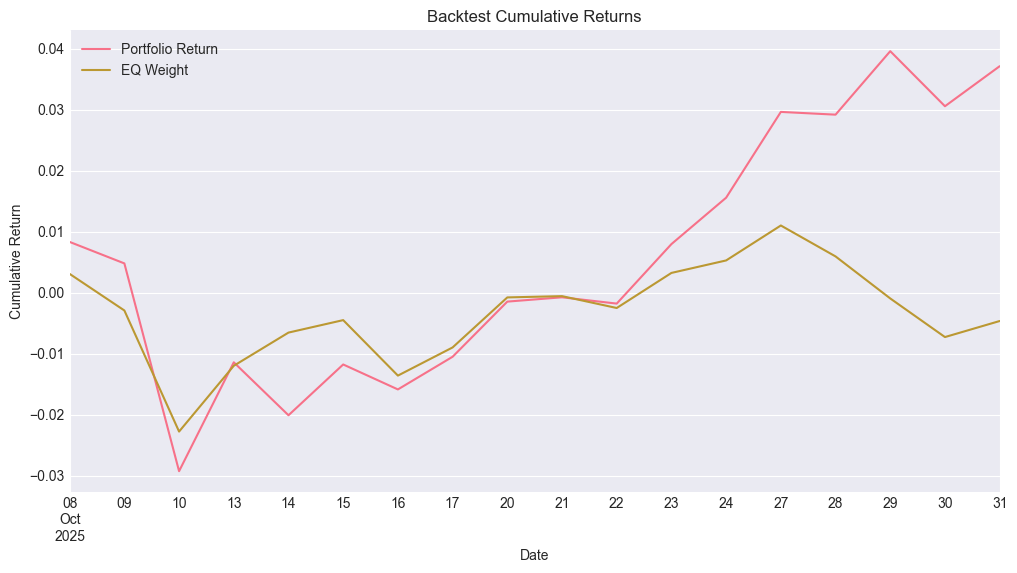

In [21]:
backtest_rets, asset_fwd_rets = get_backtest_returns(BACKTEST_LOADED)

backtest_rets.add(1).cumprod().sub(1).plot(figsize=(12, 6), title='Backtest Cumulative Returns', ylabel='Cumulative Return', xlabel='Date')

2025-10-07:	long/short = 125.0/25.0
-----------
Technology Select Sector SPDR                0.5968
Energy Select Sector SPDR                    0.3586
Utilities Select Sector SPDR                 0.1091
Consumer Discretionary Select Sector SPDR    0.0972
Health Care Select Sector SPDR               0.0884
Consumer Staples Select Sector SPDR         -0.0000
Industrial Select Sector SPDR               -0.0000
Financial Select Sector SPDR                -0.0074
Materials Select Sector SPDR                -0.2426


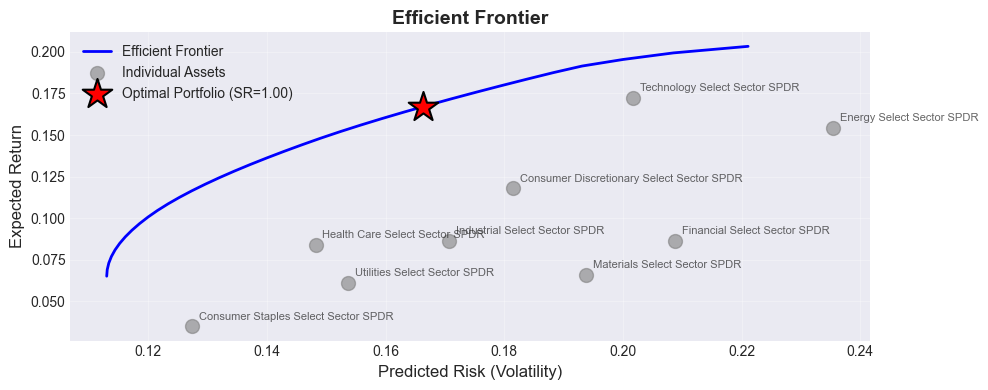

In [69]:
for rebal_date in REBAL_DATES:
    long = BACKTEST_LOADED[rebal_date].optimal_weights.where(lambda x: x>=0).sum().round(2) * 100
    short = BACKTEST_LOADED[rebal_date].optimal_weights.where(lambda x: x<0).abs().sum().round(2) * 100
    print(f"{pd.Timestamp(rebal_date).date()}:\tlong/short = {long}/{short}")
    print(f"-----------")
    print(BACKTEST_LOADED[rebal_date].optimal_weights.sort_values(ascending=False).round(4).to_string())
    BACKTEST_LOADED[rebal_date].plot_efficient_frontier(figsize=(10, 4), show_assets=True)

In [23]:
dist_validation = BACKTEST_LOADED[REBAL_DATES[-1]].optimizer_inputs_instance.simulators[ASSET_NAMES[0]].validate_distributions(verbose=True)
dist_validation


DISTRIBUTION GOODNESS-OF-FIT VALIDATION

Parameter Validity & Sample Size:
 regime distribution  n_obs  valid
      0 norminvgauss   3982   True
      1    student_t   2319   True
      2    student_t     66   True
      3 norminvgauss    346   True

Goodness-of-Fit Tests (p-values):
 regime  KS_pval  AD_pval  Chi2_pval  QQ_corr
      0 0.662176      NaN   0.074287 0.997509
      1 0.161179      NaN   0.000451 0.994965
      2 0.650773      NaN   0.177317 0.989204
      3 0.935691      NaN   0.086287 0.988071

Interpretation:
  - p-value > 0.05: Distribution fits well (cannot reject)
  - p-value < 0.05: Distribution may not fit well (reject)
  - QQ_corr > 0.95: Excellent fit
  - QQ_corr > 0.90: Good fit

✓ All distributions pass goodness-of-fit tests


,regime,distribution,n_obs,valid,KS_stat,KS_pval,AD_stat,AD_pval,Chi2_stat,Chi2_pval,QQ_corr,loc,scale,AIC
0,0,norminvgauss,3982,True,0.011515,0.662176,NaN,NaN,15.661864,0.074287,0.997509,0.003870,0.025509,NaN
1,1,student_t,2319,True,0.023228,0.161179,NaN,NaN,29.931612,0.000451,0.994965,0.000583,0.013579,NaN
2,2,student_t,66,True,0.088209,0.650773,NaN,NaN,8.934129,0.177317,0.989204,-0.011486,0.037780,NaN
3,3,norminvgauss,346,True,0.028381,0.935691,NaN,NaN,9.634252,0.086287,0.988071,0.006345,0.068032,NaN


In [24]:
sim_validation = BACKTEST_LOADED[REBAL_DATES[-1]].optimizer_inputs_instance.validate_copula_simulation(verbose=True)


COPULA SIMULATION VALIDATION
Using actual regime assignments from 1,000 simulations
Validation across ALL simulations (not just one path)

Step 1: Validating regime-dependent correlations...
  Minimum samples per regime: 50
  ✓ Regime 0 (LV Bull): Mean diff = 0.014, Max diff = 0.025, n = 14,919
  ✓ Regime 1 (LV Bear): Mean diff = 0.048, Max diff = 0.121, n = 2,218
  ✓ Regime 2 (HV Bull): Mean diff = 0.092, Max diff = 0.179, n = 140
  ✓ Regime 3 (HV Bear): Mean diff = 0.126, Max diff = 0.193, n = 723

Step 2: Validating regime concordance...
  ✓ Energy Select Sector SPDR: Mean diff = 0.137, Empirical diag = 0.351, Expected diag = 0.458
  ✓ Financial Select Sector SPDR: Mean diff = 0.150, Empirical diag = 0.487, Expected diag = 0.679
  ✓ Utilities Select Sector SPDR: Mean diff = 0.122, Empirical diag = 0.337, Expected diag = 0.436
  ⚠️ Industrial Select Sector SPDR: Mean diff = 0.201, Empirical diag = 0.442, Expected diag = 0.734
  ✓ Health Care Select Sector SPDR: Mean diff = 0.118, Em

In [25]:
portfolio = BACKTEST_LOADED[REBAL_DATES[-1]].optimizer_inputs_instance

for asset in portfolio.asset_names:
    simulator = portfolio.simulators[asset]
    print(f"\n{asset}:")
    for regime in range(4):
        if regime in simulator.regime_distributions:
            dist_type = simulator.regime_distributions[regime]['distribution']
            print(f"  Regime {regime}: {dist_type}")


Energy Select Sector SPDR:
  Regime 0: norminvgauss
  Regime 1: student_t
  Regime 2: student_t
  Regime 3: norminvgauss

Financial Select Sector SPDR:
  Regime 0: norminvgauss
  Regime 1: student_t
  Regime 2: normal
  Regime 3: student_t

Utilities Select Sector SPDR:
  Regime 0: norminvgauss
  Regime 1: student_t
  Regime 2: skewnorm
  Regime 3: skewnorm

Industrial Select Sector SPDR:
  Regime 0: norminvgauss
  Regime 1: skewnorm
  Regime 2: normal
  Regime 3: student_t

Health Care Select Sector SPDR:
  Regime 0: norminvgauss
  Regime 1: student_t
  Regime 2: skewnorm
  Regime 3: normal

Technology Select Sector SPDR:
  Regime 0: norminvgauss
  Regime 1: student_t
  Regime 2: student_t
  Regime 3: norminvgauss

Materials Select Sector SPDR:
  Regime 0: norminvgauss
  Regime 1: student_t
  Regime 2: normal
  Regime 3: student_t

Consumer Discretionary Select Sector SPDR:
  Regime 0: norminvgauss
  Regime 1: normal
  Regime 2: normal
  Regime 3: student_t

Consumer Staples Select S